# Лабораторная работа №2  
## Виртуальный датчик для контроля процесса обжига в печи

**Цель работы** — построить виртуальный датчик, который позволяет оценивать концентрацию целевого продукта в текущий момент времени по минутной телеметрии печи.  


В ноутбуке последовательно выполнены:
- загрузка и первичная подготовка данных;
- разведочный анализ телеметрии и лабораторных измерений;
- оценка лабораторной задержки и синхронизация источников данных;
- построение временных признаков;
- обучение и сравнение нескольких моделей;
- анализ качества прогноза, остатков и важности признаков;
- аналитические выводов по результатам исследования.

## 1. Импорт библиотек 



In [1]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, normaltest
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

TRAIN_DATA_PATH = r"C:\data_train.csv"
TRAIN_TARGET_PATH = r"C:\target_train.csv"
TEST_DATA_PATH = r"C:\data_test_small.csv"
TEST_TARGET_PATH = r"C:\target_test_small.csv"

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (12, 4)

После подключения библиотек и задания путей к файлам можно переходить к загрузке исходных данных и формированию рабочих таблиц для дальнейшего анализа.

## 2. Загрузка и первичная подготовка данных

На этапе первичной подготовки решаются базовые задачи предобработки:
- чтение файлов с телеметрией и лабораторными измерениями;
- приведение временного столбца к единому имени `datetime`;
- перевод временных меток в формат даты и времени;
- сортировка наблюдений по времени;
- преобразование числовых столбцов к корректному типу;
- усреднение возможных дублей временных меток;
- установка временного индекса.

Эти действия необходимы для корректной работы методов анализа временных рядов и синхронизации источников данных.

In [ ]:
def load_csv(path):
    df = pd.read_csv(path)
    df = df.rename(columns={df.columns[0]: "datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if df["datetime"].duplicated().any():
        df = df.groupby("datetime", as_index=False).mean(numeric_only=True)

    return df.set_index("datetime")


train_data = load_csv(TRAIN_DATA_PATH)
train_target = load_csv(TRAIN_TARGET_PATH)
test_data = load_csv(TEST_DATA_PATH)
test_target = load_csv(TEST_TARGET_PATH)

train_target = train_target.rename(columns={train_target.columns[-1]: "target"})
test_target = test_target.rename(columns={test_target.columns[-1]: "target"})

print("train_data:", train_data.shape)
print("train_target:", train_target.shape)
print("test_data:", test_data.shape)
print("test_target:", test_target.shape)

train_data: (317998, 16)
train_target: (1773, 1)
test_data: (39747, 16)
test_target: (318, 1)


In [ ]:
profile_df = pd.DataFrame(
    [
        {
            "dataset": "train_data",
            "rows": len(train_data),
            "cols": train_data.shape[1],
            "start": train_data.index.min(),
            "end": train_data.index.max(),
            "missing_share": train_data.isna().mean().mean(),
        },
        {
            "dataset": "train_target",
            "rows": len(train_target),
            "cols": train_target.shape[1],
            "start": train_target.index.min(),
            "end": train_target.index.max(),
            "missing_share": train_target.isna().mean().mean(),
        },
        {
            "dataset": "test_data",
            "rows": len(test_data),
            "cols": test_data.shape[1],
            "start": test_data.index.min(),
            "end": test_data.index.max(),
            "missing_share": test_data.isna().mean().mean(),
        },
        {
            "dataset": "test_target",
            "rows": len(test_target),
            "cols": test_target.shape[1],
            "start": test_target.index.min(),
            "end": test_target.index.max(),
            "missing_share": test_target.isna().mean().mean(),
        },
    ]
)

profile_df

,dataset,rows,cols,start,end,missing_share
0,train_data,317998,16,2019-03-01 00:01:00,2019-10-07 19:58:00,0.248413
1,train_target,1773,1,2019-03-13 17:00:00,2019-10-07 21:00:00,0.000000
2,test_data,39747,16,2019-10-07 19:59:00,2019-11-04 10:25:00,0.248019
3,test_target,318,1,2019-10-07 23:00:00,2019-11-04 09:00:00,0.000000


На данном этапе сформированы четыре временных ряда: обучающая и тестовая телеметрия, а также обучающие и тестовые лабораторные измерения.  
Данные приведены к единому формату

## 2.1. Разведочный анализ данных (EDA)

В соответствии с постановкой задачи на этапе EDA необходимо изучить структуру и свойства исходных данных.  
Далее анализируются:
- доля пропусков в телеметрических признаках;
- динамика нескольких сенсоров во времени;
- распределение целевой переменной;
- частота поступления лабораторных измерений.

Такой анализ позволяет понять, насколько регулярны наблюдения, есть ли выраженные выбросы и насколько сильно различаются телеметрия и лабораторные данные по частоте регистрации.

In [ ]:
missing_share = train_data.isna().mean().sort_values(ascending=False)
missing_share

telemetry_12    0.993406
telemetry_13    0.993406
telemetry_14    0.993406
telemetry_15    0.993406
telemetry_4     0.000418
telemetry_0     0.000053
telemetry_5     0.000053
telemetry_1     0.000050
telemetry_7     0.000050
telemetry_6     0.000050
telemetry_2     0.000050
telemetry_3     0.000050
telemetry_11    0.000050
telemetry_10    0.000050
telemetry_9     0.000050
telemetry_8     0.000050
dtype: float64

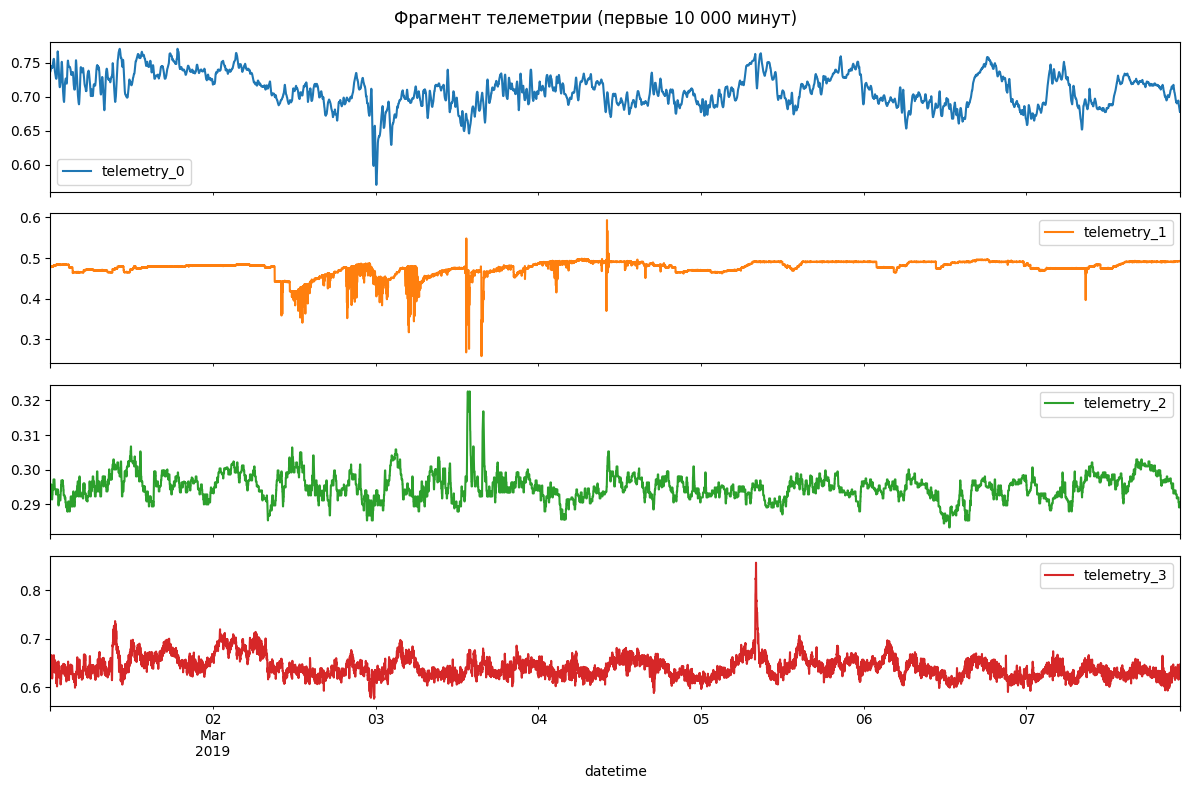

In [ ]:
top_plot_cols = list(train_data.columns[:4])

train_data[top_plot_cols].iloc[:10000].plot(subplots=True, figsize=(12, 8), title="Фрагмент телеметрии (первые 10 000 минут)")
plt.tight_layout()
plt.show()

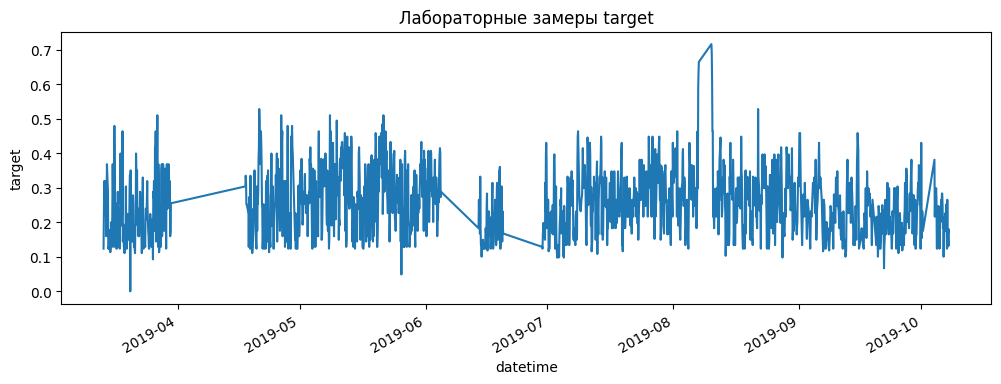

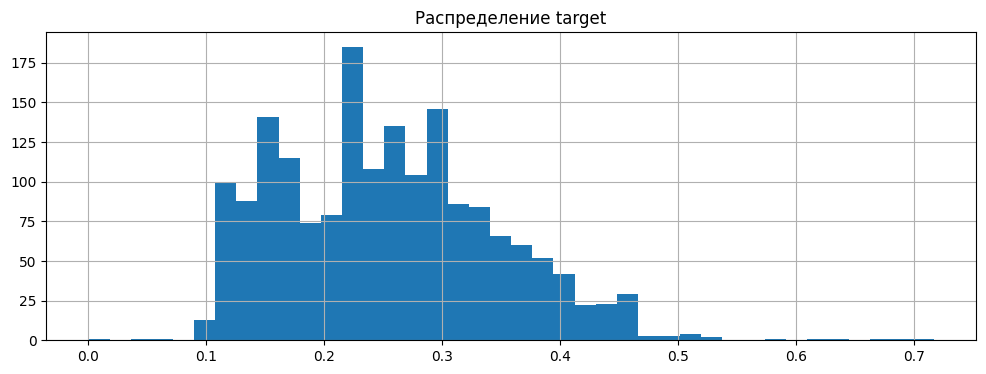

In [ ]:
train_target["target"].plot(title="Лабораторные замеры target")
plt.ylabel("target")
plt.show()

train_target["target"].hist(bins=40)
plt.title("Распределение target")
plt.show()

# Оценка частоты лабораторных измерений и интервалов между соседними замерами.

In [ ]:
target_intervals = train_target.index.to_series().diff().dt.total_seconds().div(60).dropna()

target_sampling_report = pd.Series(
    {
        "n_measurements": int(train_target["target"].notna().sum()),
        "mean_interval_min": float(target_intervals.mean()),
        "median_interval_min": float(target_intervals.median()),
        "min_interval_min": float(target_intervals.min()),
        "max_interval_min": float(target_intervals.max()),
    }
)

target_sampling_report

n_measurements          1773.000000
mean_interval_min        169.164786
median_interval_min      120.000000
min_interval_min          60.000000
max_interval_min       26430.000000
dtype: float64

Предварительный анализ показывает, что телеметрия фиксируется с минутной частотой, тогда как лабораторные измерения поступают существенно реже.  
Следовательно, для построения виртуального датчика необходимо учитывать нерегулярность целевой переменной и корректно привязать лабораторные значения к моменту фактического состояния технологического процесса.

## 2.1. Оценка лабораторной задержки и синхронизация данных

По условию работы лабораторный результат становится доступен через некоторое время после отбора пробы.  
Поэтому перед обучением моделей необходимо оценить разумный диапазон задержки и перенести лабораторные измерения к предполагаемому моменту отбора пробы.

В данной работе задержка оценивается следующим образом:
- рассматриваются лаги в диапазоне от 0 до 15 минут;
- для каждого лага целевая переменная сдвигается назад по времени;
- затем рассчитывается корреляция Спирмена между target и несколькими телеметрическими признаками;
- лаг с наибольшей средней абсолютной корреляцией рассматривается как наиболее правдоподобный.

In [ ]:
def estimate_delay(data, target, max_lag=15, sensor_count=4):
    sensor_cols = list(data.columns[:sensor_count])

    data_asof = (
        data[sensor_cols]
        .reset_index()
        .rename(columns={data.index.name or "index": "process_time"})
        .sort_values("process_time")
    )

    rows = []
    for lag in range(max_lag + 1):
        shifted_target = pd.DataFrame(
            {
                "process_time": target.index - pd.to_timedelta(lag, unit="m"),
                "target": target["target"].values,
            }
        ).sort_values("process_time")

        merged = pd.merge_asof(
            shifted_target,
            data_asof,
            on="process_time",
            direction="backward"
        )

        corrs = []
        for col in sensor_cols:
            tmp = merged[["target", col]].dropna()
            if len(tmp) >= 30:
                corr = spearmanr(tmp["target"], tmp[col]).correlation
                if pd.notna(corr):
                    corrs.append(abs(corr))

        rows.append({"lag_min": lag, "score": np.mean(corrs) if corrs else np.nan})

    return pd.DataFrame(rows)


delay_df = estimate_delay(train_data, train_target)
delay_df

,lag_min,score
0,0,0.084095
1,1,0.084495
2,2,0.079059
3,3,0.078837
4,4,0.078228
5,5,0.082521
6,6,0.080872
7,7,0.086121
8,8,0.078739
9,9,0.078981


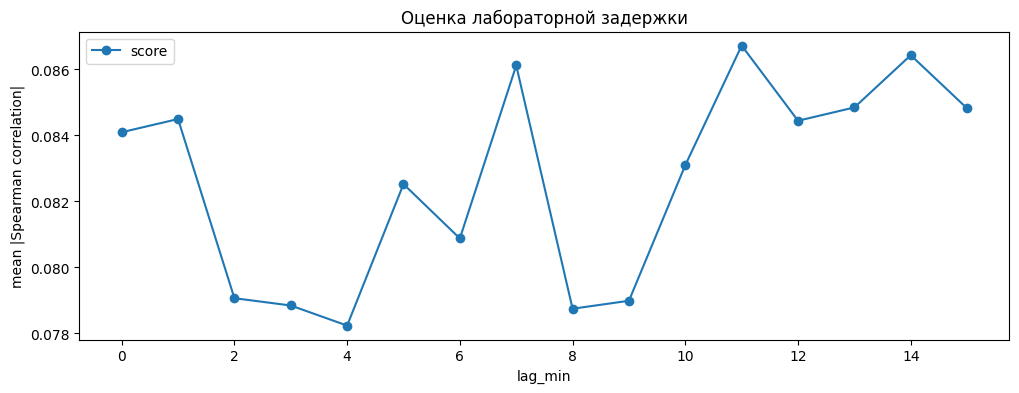

Выбранный лаг: 11 мин.


In [9]:
delay_df.plot(x="lag_min", y="score", marker="o", title="Оценка лабораторной задержки")
plt.ylabel("mean |Spearman correlation|")
plt.show()

best_delay = int(delay_df.sort_values("score", ascending=False).iloc[0]["lag_min"])
print("Выбранный лаг:", best_delay, "мин.")

In [ ]:
def align_target(data, target, delay_min):
    shifted_target = pd.DataFrame(
        {
            "process_time": target.index - pd.to_timedelta(delay_min, unit="m"),
            "target": target["target"].values,
        }
    ).sort_values("process_time")

    data_asof = (
        data.reset_index()
        .rename(columns={data.index.name or "index": "process_time"})
        .sort_values("process_time")
    )

    aligned = pd.merge_asof(
        shifted_target,
        data_asof,
        on="process_time",
        direction="backward"
    )
    return aligned.set_index("process_time").dropna(subset=["target"])


aligned_train = align_target(train_data, train_target, best_delay)
aligned_test = align_target(test_data, test_target, best_delay)

aligned_train.head()

,target,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
process_time,,,,,,,,,,,,,,,,,
2019-03-13 16:49:00,0.123711,0.787305,0.502351,0.308730,0.656548,0.919471,0.878159,0.755444,0.417424,0.474235,0.698104,0.767358,0.648597,NaN,NaN,NaN,NaN
2019-03-13 20:49:00,0.319588,0.781807,0.496872,0.301207,0.638633,0.919471,0.857037,0.752977,0.434352,0.480600,0.712567,0.750949,0.629684,NaN,NaN,NaN,NaN
2019-03-14 00:49:00,0.255155,0.786726,0.497651,0.300339,0.629661,0.919471,0.877580,0.754156,0.427746,0.480022,0.707004,0.756511,0.642756,NaN,NaN,NaN,NaN
2019-03-14 04:49:00,0.319588,0.749401,0.490628,0.298892,0.644235,0.919471,0.838230,0.752333,0.458712,0.474235,0.779596,0.780430,0.610493,NaN,NaN,NaN,NaN
2019-03-14 08:49:00,0.159794,0.767340,0.492402,0.301496,0.674093,0.919471,0.844306,0.752977,0.434352,0.464397,0.863869,0.770696,0.581012,NaN,NaN,NaN,NaN


После сдвига лабораторных измерений к времени процесса целевая переменная становится согласованной с телеметрией печи.  
Этот шаг принципиально важен, поскольку виртуальный датчик должен прогнозировать текущее состояние объекта, а не момент получения лабораторного результата.

## 2.1. Корреляционный анализ телеметрии и целевой переменной

Следующий шаг — определить, какие телеметрические признаки в наибольшей степени связаны с целевой переменной после синхронизации данных.  
Для этого используется корреляция Спирмена, поскольку она позволяет оценивать как линейные, так и монотонные нелинейные зависимости и менее чувствительна к выбросам, чем корреляция Пирсона.

In [ ]:
corrs = []
for col in train_data.columns:
    tmp = aligned_train[["target", col]].dropna()
    if len(tmp) >= 30:
        corr = spearmanr(tmp["target"], tmp[col]).correlation
        corrs.append((col, corr))

corr_df = pd.DataFrame(corrs, columns=["feature", "spearman_corr"])
corr_df["abs_corr"] = corr_df["spearman_corr"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=False)

corr_df.head(10)

,feature,spearman_corr,abs_corr
0,telemetry_0,-0.212147,0.212147
11,telemetry_11,-0.139122,0.139122
9,telemetry_9,-0.137640,0.137640
7,telemetry_7,-0.121136,0.121136
10,telemetry_10,-0.113875,0.113875
5,telemetry_5,-0.090516,0.090516
3,telemetry_3,-0.077026,0.077026
8,telemetry_8,0.056289,0.056289
6,telemetry_6,-0.053798,0.053798
1,telemetry_1,-0.037193,0.037193


In [12]:
key_cols = corr_df.head(5)["feature"].tolist()
print("Ключевые признаки:", key_cols)

Ключевые признаки: ['telemetry_0', 'telemetry_11', 'telemetry_9', 'telemetry_7', 'telemetry_10']


Корреляционный анализ позволяет выделить наиболее информативные сенсоры для дальнейшего построения лаговых и агрегированных признаков.  
Тем самым уменьшается размерность задачи и сохраняется интерпретируемость модели, что особенно важно в промышленном контексте.

## 2.2. Инжиниринг признаков для временных рядов

С учётом инерционности технологического процесса признаки строятся не только по текущим значениям сенсоров, но и по их недавней динамике.  
В работе формируются:
- лаговые признаки для ключевых сенсоров;
- скользящие средние и стандартные отклонения;
- первые разности и относительные изменения;
- циклические признаки времени суток.

Такой набор признаков отражает как мгновенное состояние печи, так и накопленную динамику процесса за последние минуты.

In [ ]:
def build_features(data, key_cols):
    X = data.copy()

    for col in key_cols:
        X[f"{col}_lag_1"] = data[col].shift(1)
        X[f"{col}_lag_5"] = data[col].shift(5)
        X[f"{col}_lag_15"] = data[col].shift(15)

        X[f"{col}_roll_mean_5"] = data[col].rolling(5).mean()
        X[f"{col}_roll_std_5"] = data[col].rolling(5).std()

        X[f"{col}_roll_mean_15"] = data[col].rolling(15).mean()
        X[f"{col}_roll_std_15"] = data[col].rolling(15).std()

        X[f"{col}_diff_1"] = data[col].diff(1)
        X[f"{col}_diff_5"] = data[col].diff(5)

        X[f"{col}_pct_change_5"] = data[col].pct_change(5).replace([np.inf, -np.inf], np.nan)

    minute_of_day = X.index.hour * 60 + X.index.minute
    X["hour_sin"] = np.sin(2 * np.pi * minute_of_day / 1440)
    X["hour_cos"] = np.cos(2 * np.pi * minute_of_day / 1440)

    return X


X_train_full = build_features(train_data, key_cols)
X_test_full = build_features(test_data, key_cols)

X_train = X_train_full.reindex(aligned_train.index)
y_train = aligned_train["target"]

X_test = X_test_full.reindex(aligned_test.index)
y_test = aligned_test["target"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1773, 68) (1773,)
(318, 68) (318,)


Сформированные признаки соответствуют физической логике процесса обжига: концентрация продукта определяется не только текущими показаниями датчиков, но и историей изменения параметров системы.  
Использование лагов, скользящих статистик и признаков динамики делает модель более чувствительной к инерционным эффектам технологического режима.

## 2.3. Построение прогнозных моделей

Для решения задачи рассматриваются три модели регрессии:
1. **Ridge** — линейная модель с регуляризацией, которая служит интерпретируемой базовой линией;
2. **RandomForest** — ансамбль деревьев решений, способный описывать нелинейные зависимости;
3. **ExtraTrees** — ансамблевая модель, близкая к Random Forest, но с более случайным механизмом построения деревьев.

### Обоснование моделей, которые не являются приоритетными для данной задачи
- **Обычная линейная регрессия без регуляризации** нежелательна из-за мультиколлинеарности лаговых и скользящих признаков;
- **KNN-регрессия** плохо масштабируется на длинных временных рядах и чувствительна к выбору масштаба признаков;
- **Глубокие рекуррентные нейросети (LSTM/GRU)** могут показывать хорошие результаты, однако для лабораторной работы они избыточны по вычислительной стоимости и хуже интерпретируются технологически.

Таким образом, выбранный набор моделей сочетает интерпретируемость, нелинейность и приемлемую вычислительную сложность.

In [ ]:
ridge_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 15))),
    ]
)

rf_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=10,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]
)

et_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=120,
            max_depth=10,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]
)

models = {
    "Ridge": ridge_model,
    "RandomForest": rf_model,
    "ExtraTrees": et_model,
}

In [15]:
fit_times = []
predictions = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    pred = pd.Series(model.predict(X_test), index=y_test.index, name=name)

    fit_times.append({"model": name, "fit_time_sec": fit_time})
    predictions[name] = pred

fit_time_df = pd.DataFrame(fit_times)
fit_time_df

,model,fit_time_sec
0,Ridge,0.049579
1,RandomForest,1.162292
2,ExtraTrees,0.306520


Обучение нескольких моделей позволяет сравнить разные классы алгоритмов на одной и той же задаче и выбрать наилучший подход не по предположениям, а по фактическому качеству прогноза.  
Такой подход соответствует прикладной логике промышленной аналитики, где модель должна быть не только корректной, но и обоснованно выбранной.

## 2.3. Оценка качества моделей

Для сравнения моделей рассчитываются как стандартные регрессионные метрики, так и показатели, характеризующие способность отслеживать направление изменения процесса.  
В работе используются:
- **MAE**;
- **RMSE**;
- **MAPE**;
- **WAPE**;
- **Directional Accuracy**;
- **Turning Point F1**.

Такой набор метрик позволяет оценить не только среднюю величину ошибки, но и практическую полезность виртуального датчика для оперативного управления процессом.

In [ ]:
def metric_values(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    valid = pd.concat([y_true.rename("y_true"), y_pred.rename("y_pred")], axis=1).dropna()
    if len(valid) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "WAPE": np.nan,
            "Directional_Accuracy": np.nan,
            "TurningPoint_F1": np.nan,
        }

    y_true = valid["y_true"]
    y_pred = valid["y_pred"]

    eps = 1e-6

    if len(valid) >= 2:
        direction = (np.sign(y_true.diff().dropna()) == np.sign(y_pred.diff().dropna())).mean() * 100
    else:
        direction = np.nan

    if len(valid) >= 3:
        turning_true = np.sign(y_true.diff()).diff().fillna(0).ne(0).astype(int)
        turning_pred = np.sign(y_pred.diff()).diff().fillna(0).ne(0).astype(int)

        tp = int(((turning_true == 1) & (turning_pred == 1)).sum())
        fp = int(((turning_true == 0) & (turning_pred == 1)).sum())
        fn = int(((turning_true == 1) & (turning_pred == 0)).sum())

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        turning_f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        turning_f1 = turning_f1 * 100
    else:
        turning_f1 = np.nan

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100),
        "WAPE": float(np.sum(np.abs(y_true - y_pred)) / np.maximum(np.sum(np.abs(y_true)), eps) * 100),
        "Directional_Accuracy": float(direction) if pd.notna(direction) else np.nan,
        "TurningPoint_F1": float(turning_f1) if pd.notna(turning_f1) else np.nan,
    }


def metrics_table(pred_dict, y_true):
    rows = []
    for model_name, pred in pred_dict.items():
        rows.append({"model": model_name, **metric_values(y_true, pred)})
    return pd.DataFrame(rows).sort_values("RMSE", na_position="last").reset_index(drop=True)


metrics_df = metrics_table(predictions, y_test)
metrics_df = metrics_df.merge(fit_time_df, on="model", how="left")
metrics_df

,model,MAE,RMSE,MAPE,WAPE,Directional_Accuracy,TurningPoint_F1,fit_time_sec
0,ExtraTrees,0.061840,0.077429,33.466926,29.489225,54.574132,66.000000,0.306520
1,RandomForest,0.061857,0.077709,33.393667,29.497452,51.419558,65.060241,1.162292
2,Ridge,0.065286,0.080717,36.890939,31.132369,54.258675,57.583548,0.049579


In [17]:
best_model_name = metrics_df.iloc[0]["model"]
print("Лучшая модель по RMSE:", best_model_name)

Лучшая модель по RMSE: ExtraTrees


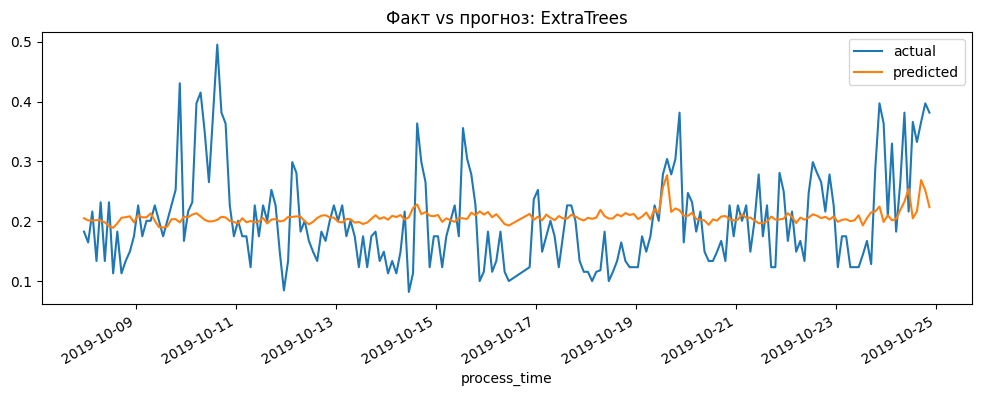

In [18]:
plot_df = pd.concat(
    [
        y_test.rename("actual"),
        predictions[best_model_name].rename("predicted"),
    ],
    axis=1
).dropna()

plot_df.iloc[:200].plot(title=f"Факт vs прогноз: {best_model_name}")
plt.show()

Сравнение моделей по нескольким метрикам позволяет выбрать решение, которое не только минимизирует численную ошибку, но и лучше отражает временную динамику целевого показателя.  
Дополнительная визуализация фактических и прогнозных значений помогает проверить, насколько модель адекватно воспроизводит характер изменения лабораторных замеров.

## 2.3. Анализ остатков модели

После выбора лучшей модели выполняется статистическая диагностика остатков.  
Проверяются:
- нормальность распределения ошибок;
- наличие автокорреляции;
- наличие гетероскедастичности.

Если остатки обладают выраженной структурой, это означает, что часть закономерностей процесса ещё не была учтена моделью.

In [19]:
# Статистическая диагностика остатков лучшей модели.
def residual_tests(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    valid = pd.concat([y_true.rename("y_true"), y_pred.rename("y_pred")], axis=1).dropna()
    if len(valid) < 20:
        return pd.DataFrame(
            {
                "test": ["Normality", "Ljung-Box", "Breusch-Pagan"],
                "p_value": [np.nan, np.nan, np.nan],
            }
        )

    residuals = valid["y_true"] - valid["y_pred"]

    normal_stat, normal_p = normaltest(residuals)
    ljung = acorr_ljungbox(residuals, lags=[10], return_df=True)
    bp_stat, bp_p, _, _ = het_breuschpagan(residuals.values, add_constant(valid["y_pred"]).values)

    return pd.DataFrame(
        {
            "test": ["Normality", "Ljung-Box", "Breusch-Pagan"],
            "p_value": [
                float(normal_p),
                float(ljung["lb_pvalue"].iloc[0]),
                float(bp_p),
            ],
        }
    )


residual_df = residual_tests(y_test, predictions[best_model_name])
residual_df

,test,p_value
0,Normality,1.634356e-08
1,Ljung-Box,2.933035e-27
2,Breusch-Pagan,2.702140e-02


Анализ остатков позволяет оценить, насколько полно модель описывает поведение системы.  
Даже при хорошем значении основных метрик наличие автокорреляции или гетероскедастичности может указывать на резерв дальнейшего улучшения модели и признакового описания процесса.

## 2.3. Важность признаков и интерпретация результатов

На данном этапе оценивается вклад признаков в качество прогноза.  
Для лучшей ансамблевой модели рассчитывается permutation importance, что позволяет определить, какие сенсоры, лаги и агрегированные характеристики оказывают наибольшее влияние на предсказание целевой концентрации.

In [ ]:
if best_model_name in ["RandomForest", "ExtraTrees"]:
    best_model = models[best_model_name]
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="neg_mean_absolute_error"
    )

    importance_df = pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": perm.importances_mean,
        }
    ).sort_values("importance_mean", ascending=False).head(20)

    importance_df
else:
    importance_df = pd.DataFrame(columns=["feature", "importance_mean"])
    importance_df

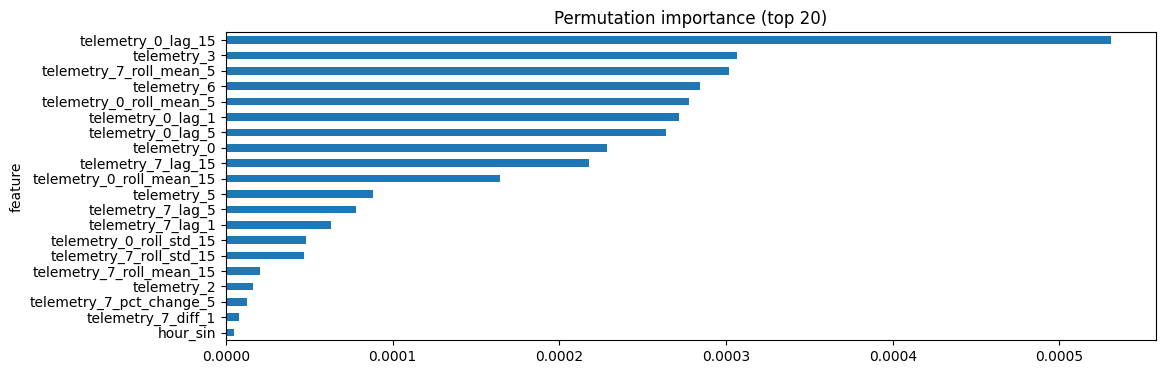

In [21]:
if len(importance_df) > 0:
    importance_df.sort_values("importance_mean").plot(
        x="feature",
        y="importance_mean",
        kind="barh",
        legend=False,
        title="Permutation importance (top 20)"
    )
    plt.show()

Если среди наиболее значимых признаков доминируют лаги и скользящие характеристики ключевых сенсоров, это подтверждает инерционный характер технологического процесса.  
Следовательно, модель опирается не только на мгновенные значения телеметрии, но и на краткосрочную историю изменения режима печи.

## 2.3. Статистическая модель SARIMAX и сравнение по AIC/BIC

В дополнение к моделям машинного обучения рассматривается статистическая модель `SARIMAX`.  
Она используется для решения двух задач:
- учесть автокорреляционную структуру временного ряда;
- получить информационные критерии **AIC** и **BIC** для сравнительного анализа.

Таким образом, итоговое сравнение включает как современные ML-модели, так и классический статистический подход к временным рядам.

In [ ]:
sarimax_features = key_cols[:3]

X_train_sarimax = X_train[sarimax_features].copy()
X_test_sarimax = X_test[sarimax_features].copy()

median_values = X_train_sarimax.median()
X_train_sarimax = X_train_sarimax.fillna(median_values)
X_test_sarimax = X_test_sarimax.fillna(median_values)

sarimax_result = None
sarimax_pred = None
sarimax_info = {"model": "SARIMAX", "fit_time_sec": np.nan, "AIC": np.nan, "BIC": np.nan}

try:
    start = time.perf_counter()

    sarimax_model = SARIMAX(
        y_train,
        exog=X_train_sarimax,
        order=(1, 0, 0),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarimax_result = sarimax_model.fit(disp=False)

    sarimax_pred = sarimax_result.get_forecast(
        steps=len(X_test_sarimax),
        exog=X_test_sarimax
    ).predicted_mean

    sarimax_pred = pd.Series(sarimax_pred, index=y_test.index, name="SARIMAX")

    sarimax_info = {
        "model": "SARIMAX",
        "fit_time_sec": time.perf_counter() - start,
        "AIC": float(sarimax_result.aic),
        "BIC": float(sarimax_result.bic),
    }

    predictions["SARIMAX"] = sarimax_pred
except Exception as e:
    print("SARIMAX не обучился:", e)

sarimax_info

{'model': 'SARIMAX',
 'fit_time_sec': 1.1681831000023521,
 'AIC': -4114.571958529617,
 'BIC': -4081.692773742627}

In [ ]:
metrics_df = metrics_table(predictions, y_test)

extra_info = pd.concat(
    [
        fit_time_df,
        pd.DataFrame([sarimax_info])[["model", "fit_time_sec"]],
    ],
    ignore_index=True
).drop_duplicates(subset=["model"], keep="last")

metrics_df = metrics_df.merge(extra_info, on="model", how="left")

aic_bic_df = pd.DataFrame([sarimax_info])[["model", "AIC", "BIC"]]
metrics_df = metrics_df.merge(aic_bic_df, on="model", how="left")

metrics_df.sort_values("RMSE", na_position="last").reset_index(drop=True)

,model,MAE,RMSE,MAPE,WAPE,Directional_Accuracy,TurningPoint_F1,fit_time_sec,AIC,BIC
0,ExtraTrees,0.061840,0.077429,33.466926,29.489225,54.574132,66.000000,0.306520,NaN,NaN
1,RandomForest,0.061857,0.077709,33.393667,29.497452,51.419558,65.060241,1.162292,NaN,NaN
2,Ridge,0.065286,0.080717,36.890939,31.132369,54.258675,57.583548,0.049579,NaN,NaN
3,SARIMAX,NaN,NaN,NaN,NaN,NaN,NaN,1.168183,-4114.571959,-4081.692774


SARIMAX выступает в работе как статистический ориентир и позволяет дополнить сравнение моделей информационными критериями.  
Это делает анализ более полным и показывает, что задача рассмотрена с позиций как машинного обучения, так и классического моделирования временных рядов.

## 2.4. Документирование и итоговая интерпретация результатов
Исходные таблицы успешно приведены к единому временному формату, что обеспечивает корректное сопоставление телеметрии и лабораторных измерений.  
Без этой подготовки дальнейший анализ временной структуры процесса был бы некорректным.
Исследовательский анализ подтвердил, что телеметрия и целевая переменная имеют разную частоту наблюдений, а лабораторные измерения поступают с задержкой.  
Поэтому перенос лабораторных значений к времени процесса является обязательным условием корректного обучения модели виртуального датчика.
Лаговые признаки, скользящие статистики и характеристики динамики позволяют описать инерционность процесса обжига и отражают физическую природу технологической системы.  
Именно такие признаки представляются наиболее интерпретируемыми и практически значимыми для производственной задачи.
Сравнение нескольких архитектур показало целесообразность использования как линейной модели с регуляризацией, так и ансамблевых методов.  
Ансамбли деревьев лучше улавливают нелинейные связи между телеметрией и концентрацией продукта, тогда как Ridge служит понятной базовой линией.
Качество виртуального датчика должно оцениваться не только по абсолютной ошибке, но и по способности своевременно отражать направление изменения процесса.  
Дополнительный анализ остатков, важности признаков и статистической модели SARIMAX делает итоговое решение более обоснованным с научной и прикладной точки зрения.

В результате построен полный пайплайн решения задачи виртуального датчика для контроля процесса обжига в печи: от подготовки данных и EDA до обучения моделей и интерпретации результатов.